--- Starting Feature Engineering: USDA WASDE Fundamentals ---
Pivoting data structure...
Calculating Stocks-to-Use Ratio and MoM Ending Stocks Shift...
Reindexing to daily frequency and applying forward-fill (Step-Function)...
Generating WASDE diagnostic graphs...


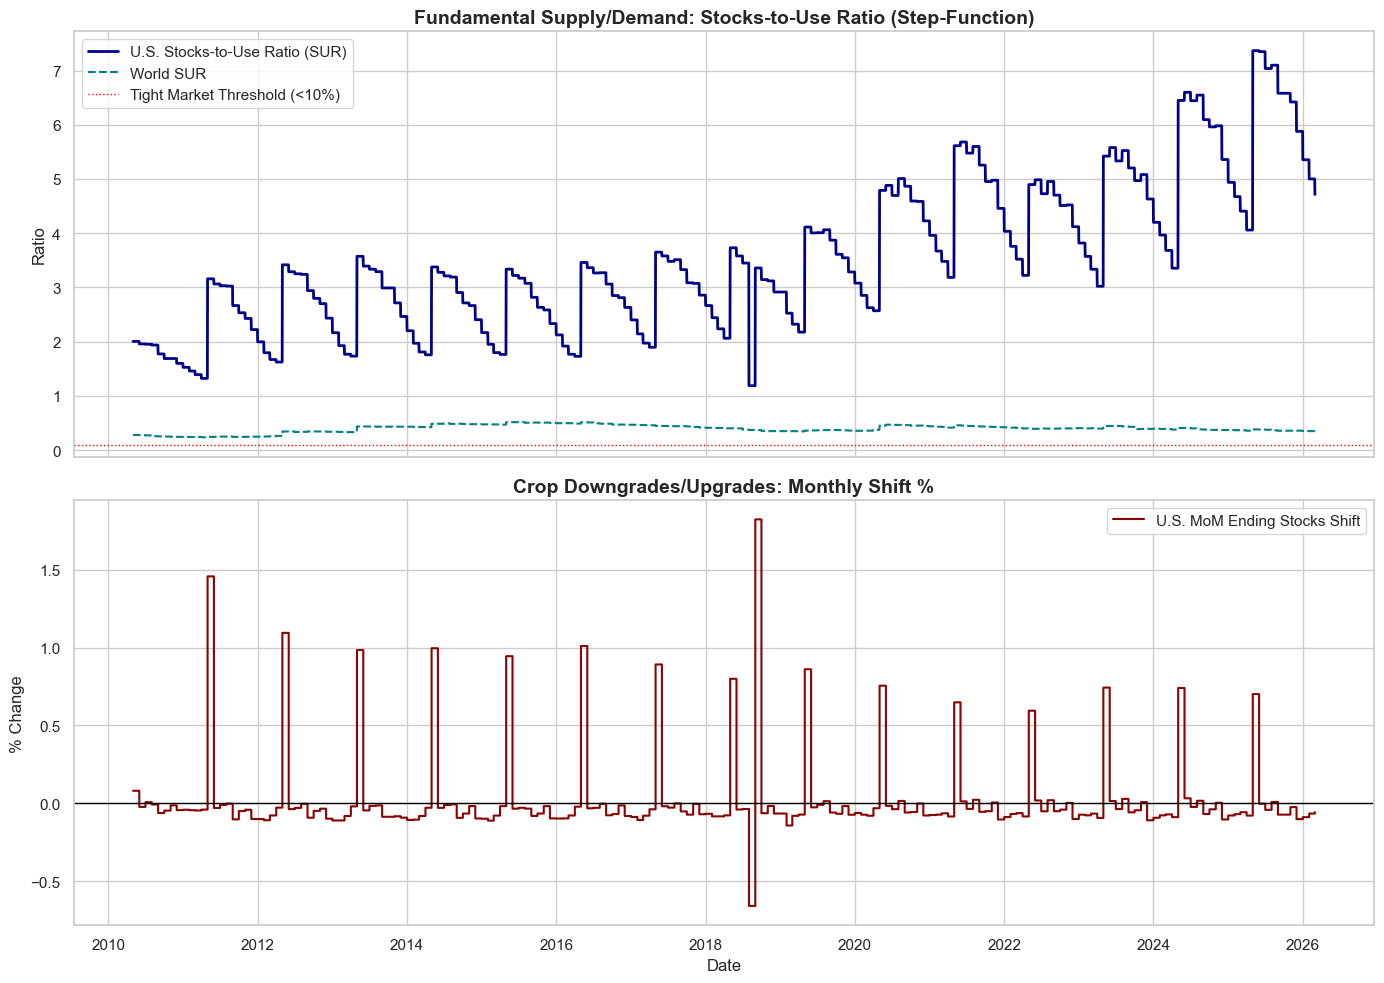


Success! Semi-cleaned WASDE dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\wasde_engineered_V.csv
           Date    US_SUR  US_MoM_ES_Shift  World_SUR  World_MoM_ES_Shift
5804 2026-02-20  5.000607        -0.065964   0.349665           -0.006766
5805 2026-02-21  5.000607        -0.065964   0.349665           -0.006766
5806 2026-02-22  5.000607        -0.065964   0.349665           -0.006766
5807 2026-02-23  5.000607        -0.065964   0.349665           -0.006766
5808 2026-02-24  5.000607        -0.065964   0.349665           -0.006766
5809 2026-02-25  5.000607        -0.065964   0.349665           -0.006766
5810 2026-02-26  5.000607        -0.065964   0.349665           -0.006766
5811 2026-02-27  5.000607        -0.065964   0.349665           -0.006766
5812 2026-02-28  5.000607        -0.065964   0.349665           -0.006766
5813 2026-03-01  4.712985        -0.057517   0.349908            0.000299


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, r"Data_Extraction\Raw_Data_Folder")
clean_folder = os.path.join(base_dir, r"Data_Cleaning\Semi_Clean_Datasets")

os.makedirs(clean_folder, exist_ok=True)

# Adjust this filename if your raw WASDE file is named differently
input_file = os.path.join(raw_folder, "wasde_cotton_filtered.csv") 

def engineer_wasde_features():
    print("--- Starting Feature Engineering: USDA WASDE Fundamentals ---")
    
    if not os.path.exists(input_file):
        print(f"Error: Could not find {input_file}")
        return

    # 2. Load Data
    df = pd.read_csv(input_file)
    df.columns = df.columns.str.strip()
    df['ReportDate'] = pd.to_datetime(df['ReportDate'])
    
    # 3. Handle WASDE Multi-Year Overlaps
    # WASDE reports often contain multiple marketing years (e.g., 08/09, 09/10, 10/11) in the same release.
    # We group by Date, Attribute, and Region and take the mean to resolve duplicates before pivoting.
    df = df.groupby(['ReportDate', 'Attribute', 'Region'])['Value'].mean().reset_index()
    
    # 4. Pivot the Data
    # We need 'Ending Stocks' and 'Total Use' as their own columns, not rows
    print("Pivoting data structure...")
    df_pivot = df.pivot_table(index='ReportDate', columns=['Region', 'Attribute'], values='Value').reset_index()
    
    # Flatten the multi-level columns created by the pivot
    df_pivot.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_pivot.columns.values]
    df_pivot = df_pivot.rename(columns={'ReportDate': 'Date'})
    df_pivot = df_pivot.sort_values('Date').reset_index(drop=True)
    
    # 5. Complex Feature Generation (Methodology Aligned)
    print("Calculating Stocks-to-Use Ratio and MoM Ending Stocks Shift...")
    
    # U.S. Features
    if 'United States_Ending Stocks' in df_pivot.columns and 'United States_Total Use' in df_pivot.columns:
        df_pivot['US_SUR'] = df_pivot['United States_Ending Stocks'] / df_pivot['United States_Total Use']
        df_pivot['US_MoM_ES_Shift'] = df_pivot['United States_Ending Stocks'].pct_change()
        
    # World Features
    if 'World_Ending Stocks' in df_pivot.columns and 'World_Total Use' in df_pivot.columns:
        df_pivot['World_SUR'] = df_pivot['World_Ending Stocks'] / df_pivot['World_Total Use']
        df_pivot['World_MoM_ES_Shift'] = df_pivot['World_Ending Stocks'].pct_change()
    
    # 6. Change Frequency from Monthly to Daily (The Step-Function)
    print("Reindexing to daily frequency and applying forward-fill (Step-Function)...")
    full_date_range = pd.date_range(start=df_pivot['Date'].min(), end=df_pivot['Date'].max(), freq='D')
    
    # Set Date as index, reindex to the daily calendar, and forward fill
    df_daily = df_pivot.set_index('Date').reindex(full_date_range)
    df_daily = df_daily.ffill() # THIS is the critical step-function command
    
    # Reset index to bring Date back as a regular column
    df_daily = df_daily.rename_axis('Date').reset_index()
    
    # Drop initial rows that have NaNs before the very first report's MoM shift calculates
    if 'US_SUR' in df_daily.columns:
        df_daily = df_daily.dropna(subset=['US_SUR', 'US_MoM_ES_Shift']).copy()
    else:
        df_daily = df_daily.dropna().copy()
    
    # 7. Data Visualization
    print("Generating WASDE diagnostic graphs...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top Plot: Stocks-to-Use Ratio (SUR)
    if 'US_SUR' in df_daily.columns:
        ax1.plot(df_daily['Date'], df_daily['US_SUR'], color='darkblue', linewidth=2, label='U.S. Stocks-to-Use Ratio (SUR)')
    if 'World_SUR' in df_daily.columns:
        ax1.plot(df_daily['Date'], df_daily['World_SUR'], color='teal', linewidth=1.5, linestyle='--', label='World SUR')
    
    ax1.axhline(0.10, color='red', linewidth=1, linestyle=':', label='Tight Market Threshold (<10%)')
    ax1.set_title('Fundamental Supply/Demand: Stocks-to-Use Ratio (Step-Function)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Ratio', fontsize=12)
    ax1.legend()
    
    # Bottom Plot: MoM Ending Stocks Shift
    if 'US_MoM_ES_Shift' in df_daily.columns:
        # We use a step plot here to visualize the sudden percentage shocks
        ax2.step(df_daily['Date'], df_daily['US_MoM_ES_Shift'], color='darkred', linewidth=1.5, label='U.S. MoM Ending Stocks Shift', where='post')
    
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_title('Crop Downgrades/Upgrades: Monthly Shift %', fontsize=14, fontweight='bold')
    ax2.set_ylabel('% Change', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 8. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "wasde_engineered_V.csv")
    
    # Keep only the engineered features to keep the master merge clean
    cols_to_keep = ['Date']
    if 'US_SUR' in df_daily.columns: cols_to_keep.extend(['US_SUR', 'US_MoM_ES_Shift'])
    if 'World_SUR' in df_daily.columns: cols_to_keep.extend(['World_SUR', 'World_MoM_ES_Shift'])
        
    df_export = df_daily[cols_to_keep]
    df_export.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Semi-cleaned WASDE dataset saved to: {output_path}")
    print(df_export.tail(10))

if __name__ == "__main__":
    engineer_wasde_features()